<a href="https://colab.research.google.com/github/Rahulnema04/cifar10-from-scratch/blob/main/phase1_manual_backprop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

# CIFAR-10 loads automatically from torchvision — no manual download needed
transform = transforms.Compose([transforms.ToTensor()])

train_data = datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform)
test_data  = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Classes: 0=airplane, 1=automobile, 2=bird, 3=cat, 4=deer,
#          5=dog, 6=frog, 7=horse, 8=ship, 9=truck

100%|██████████| 170M/170M [00:03<00:00, 48.9MB/s]


In [3]:
def get_binary_numpy(dataset, class_a=0, class_b=1):
    X, y = [], []
    for img, label in dataset:
        if label in (class_a, class_b):
            X.append(img.numpy().flatten())   # 32x32x3 → 3072 flat vector
            y.append(0 if label == class_a else 1)
    X = np.array(X, dtype=np.float32)        # shape: (N, 3072)
    y = np.array(y, dtype=np.float32)        # shape: (N,)
    return X, y

X_train, y_train = get_binary_numpy(train_data)
X_test,  y_test  = get_binary_numpy(test_data)

print(X_train.shape, y_train.shape)   # should be (10000, 3072) (2000, 3072) approx

(10000, 3072) (10000,)


In [4]:
np.random.seed(42)

input_size  = 3072
hidden_size = 128
output_size = 1       # binary → single sigmoid output

# He initialization (good default for ReLU networks)
W1 = np.random.randn(input_size,  hidden_size) * np.sqrt(2.0 / input_size)
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size)
b2 = np.zeros((1, output_size))

In [5]:
def relu(z):
    return np.maximum(0, z)

def relu_deriv(z):
    return (z > 0).astype(float)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_pred, y_true):
    epsilon = 1e-8
    y_pred = np.clip(y_pred, epsilon, 1.0 - epsilon)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# Quick tests
print("ReLU test:", relu(np.array([-2, 0, 3])))
print("Sigmoid test:", sigmoid(np.array([0])))
print("BCE test (perfect match):", binary_cross_entropy(np.array([0.9]), np.array([1.0])))
print("BCE test (confident wrong):", binary_cross_entropy(np.array([0.1]), np.array([1.0])))

ReLU test: [0 0 3]
Sigmoid test: [0.5]
BCE test (perfect match): 0.10536051565782628
BCE test (confident wrong): 2.3025850929940455


In [6]:
def forward(X, W1, b1, W2, b2):
    # --- Layer 1 ---
    z1 = X @ W1 + b1        # (N, 3072) @ (3072, 128) = (N, 128)
    a1 = relu(z1)            # still (N, 128), negatives zeroed out

    # --- Layer 2 ---
    z2 = a1 @ W2 + b2       # (N, 128) @ (128, 1) = (N, 1)
    a2 = sigmoid(z2)         # still (N, 1), values now between 0 and 1

    # save everything — backward() will need all of these
    cache = (X, z1, a1, z2, a2)
    return a2, cache

In [7]:
def backward(cache, y_true, W2):
    X, z1, a1, z2, a2 = cache
    N = X.shape[0]

    # ─── Output layer gradients ───────────────────────────────────────────

    # How wrong were we, on average, per sample
    # Shape: (N, 1) — one error value per training example
    dz2 = (a2 - y_true.reshape(-1, 1)) / N

    # How much did each W2 weight contribute to that error?
    # a1 is (N, 128), dz2 is (N, 1) → dW2 must be (128, 1) — same shape as W2
    dW2 = a1.T @ dz2

    # Bias gradient — just average the error signal across the batch
    # Sum over N examples, keep shape (1, 1)
    db2 = np.sum(dz2, axis=0, keepdims=True)

    # ─── Hidden layer gradients ───────────────────────────────────────────

    # Pass the error signal backwards through W2
    # dz2 is (N, 1), W2.T is (1, 128) → da1 is (N, 128)
    da1 = dz2 @ W2.T

    # ReLU gate: zero out gradient for neurons that were inactive (z1 <= 0)
    # These neurons contributed nothing to the output, so they get no update
    dz1 = da1 * relu_deriv(z1)     # elementwise multiply, shape stays (N, 128)

    # How much did each W1 weight contribute to that error?
    # X.T is (3072, N), dz1 is (N, 128) → dW1 must be (3072, 128) — same shape as W1
    dW1 = X.T @ dz1

    # Bias gradient for layer 1
    db1 = np.sum(dz1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2

In [8]:
a2, cache = forward(X_train[:256], W1, b1, W2, b2)
dW1, db1, dW2, db2 = backward(cache, y_train[:256], W2)

# Every gradient must match the shape of its corresponding parameter
print(dW1.shape)   # (3072, 128) — same as W1
print(db1.shape)   # (1, 128)    — same as b1
print(dW2.shape)   # (128, 1)    — same as W2
print(db2.shape)   # (1, 1)      — same as b2


(3072, 128)
(1, 128)
(128, 1)
(1, 1)


In [9]:
# Gradient magnitudes should be small but nonzero
print("dW1 mean abs:", np.abs(dW1).mean())   # expect 1e-4 to 1e-2
print("dW2 mean abs:", np.abs(dW2).mean())   # expect 1e-3 to 1e-1

# Loss should be going down
# If it's going up, flip the sign of your update in Cell 7
# If it's flat at 0.693, your gradients aren't flowing (log(2) ≈ 0.693 = random chance loss)

dW1 mean abs: 0.0027741250235872495
dW2 mean abs: 0.03251204998292497


Epoch   0 | Loss: 25.8184
Epoch  10 | Loss: 16.8202
Epoch  20 | Loss: 15.7339
Epoch  30 | Loss: 14.5336
Epoch  40 | Loss: 14.0928


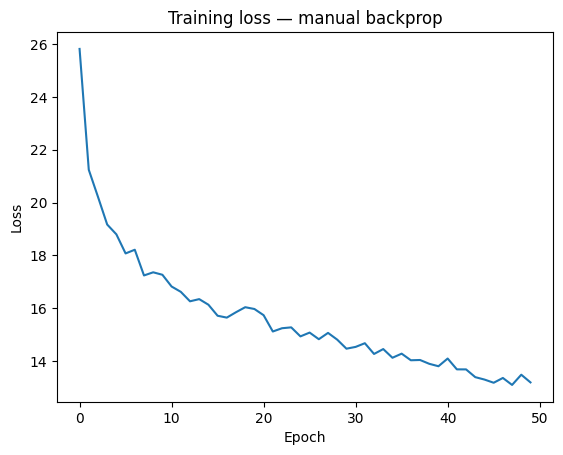

In [10]:
lr = 0.01
epochs = 50
batch_size = 256
losses = []

for epoch in range(epochs):
    # Shuffle
    idx = np.random.permutation(len(X_train))
    X_s, y_s = X_train[idx], y_train[idx]

    epoch_loss = 0
    for i in range(0, len(X_s), batch_size):
        Xb = X_s[i:i+batch_size]
        yb = y_s[i:i+batch_size]

        a2, cache = forward(Xb, W1, b1, W2, b2)
        loss = binary_cross_entropy(a2.squeeze(), yb)
        epoch_loss += loss

        dW1, db1, dW2, db2 = backward(cache, yb, W2)

        # SGD update — implement this
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    losses.append(epoch_loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Loss: {epoch_loss:.4f}")

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss — manual backprop")
plt.show()